# RAM Memory Requirements for Quantum State Vector Simulation

A quantum system of $n$ qubits is described by a state vector with $2^n$ complex amplitudes.  
In double precision (`complex128`), each amplitude requires **16 bytes** (2 x 8 bytes for real and imaginary parts).

$$\text{Memory} = 2^n \times 16 \text{ bytes} = 2^{n+4} \text{ bytes}$$

### References

1. **Haner & Steiger (2017)** - *0.5 Petabyte Simulation of a 45-Qubit Quantum Circuit*, SC'17. [arXiv:1704.01127](https://arxiv.org/abs/1704.01127)  
2. **Jones et al. (2019)** - *QuEST and High Performance Simulation of Quantum Computers*, Sci. Rep. 9, 10736. [DOI:10.1038/s41598-019-47174-9](https://doi.org/10.1038/s41598-019-47174-9)  
3. **Arute et al. (2019)** - *Quantum supremacy using a programmable superconducting processor*, Nature 574, 505-510. [DOI:10.1038/s41586-019-1666-5](https://doi.org/10.1038/s41586-019-1666-5)  
4. **De Raedt et al. (2025)** - *Universal Quantum Simulation of 50 Qubits on JUPITER*, [arXiv:2511.03359](https://arxiv.org/abs/2511.03359)  
5. **NVIDIA cuStateVec** - GPU memory limits: 30 qubits (16 GB) to 33 qubits (80 GB). [Developer Blog](https://developer.nvidia.com/blog/accelerating-quantum-circuit-simulation-with-nvidia-custatevec/)  
6. **FiQCI/LUMI (2025)** - 44 qubits = 256 TB on LUMI supercomputer. [Article](https://fiqci.fi/publications/2025-04-01-LUMI-quantum-simulations-qiskit-aer)  
7. **AWS HPC Blog (2022)** - 44-qubit simulation using AWS ParallelCluster. [Blog](https://aws.amazon.com/blogs/hpc/simulating-44-qubit-quantum-circuits-using-aws-parallelcluster/)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
# --- Data ---
# Theoretical: Memory = 2^n * 16 bytes (complex128 state vector)
qubits = np.arange(1, 51)
memory_bytes = 2.0**qubits * 16  # bytes
memory_gb = memory_bytes / (1024**3)

# Real-world data points confirmed by papers/benchmarks
real_data = {
    # label: (qubits, memory_GB, reference)
    "NVIDIA T4/V100 (16 GB)":       (30, 16,          "NVIDIA cuStateVec"),
    "NVIDIA A100 80GB":              (33, 128,         "NVIDIA cuStateVec"),
    "DGX A100 8xGPU (640 GB)":       (36, 640,         "NVIDIA cuQuantum"),
    "QuEST on ARCHER (2048 nodes)":  (38, 2048,        "Jones et al. 2019"),
    "QuEST reported (40q = 16 TiB)": (40, 16 * 1024,   "Jones et al. 2019"),
    "LUMI / AWS (44q = 256 TB)":     (44, 256 * 1024,  "FiQCI 2025 / AWS 2022"),
    "Haner & Steiger (0.5 PB)":      (45, 512 * 1024,  "Haner & Steiger 2017"),
    "De Raedt et al. JUPITER":       (50, 16 * 1024**2 / 1024,  "De Raedt et al. 2025"),
}

real_qubits = [v[0] for v in real_data.values()]
real_mem_gb = [v[1] for v in real_data.values()]
real_labels = list(real_data.keys())

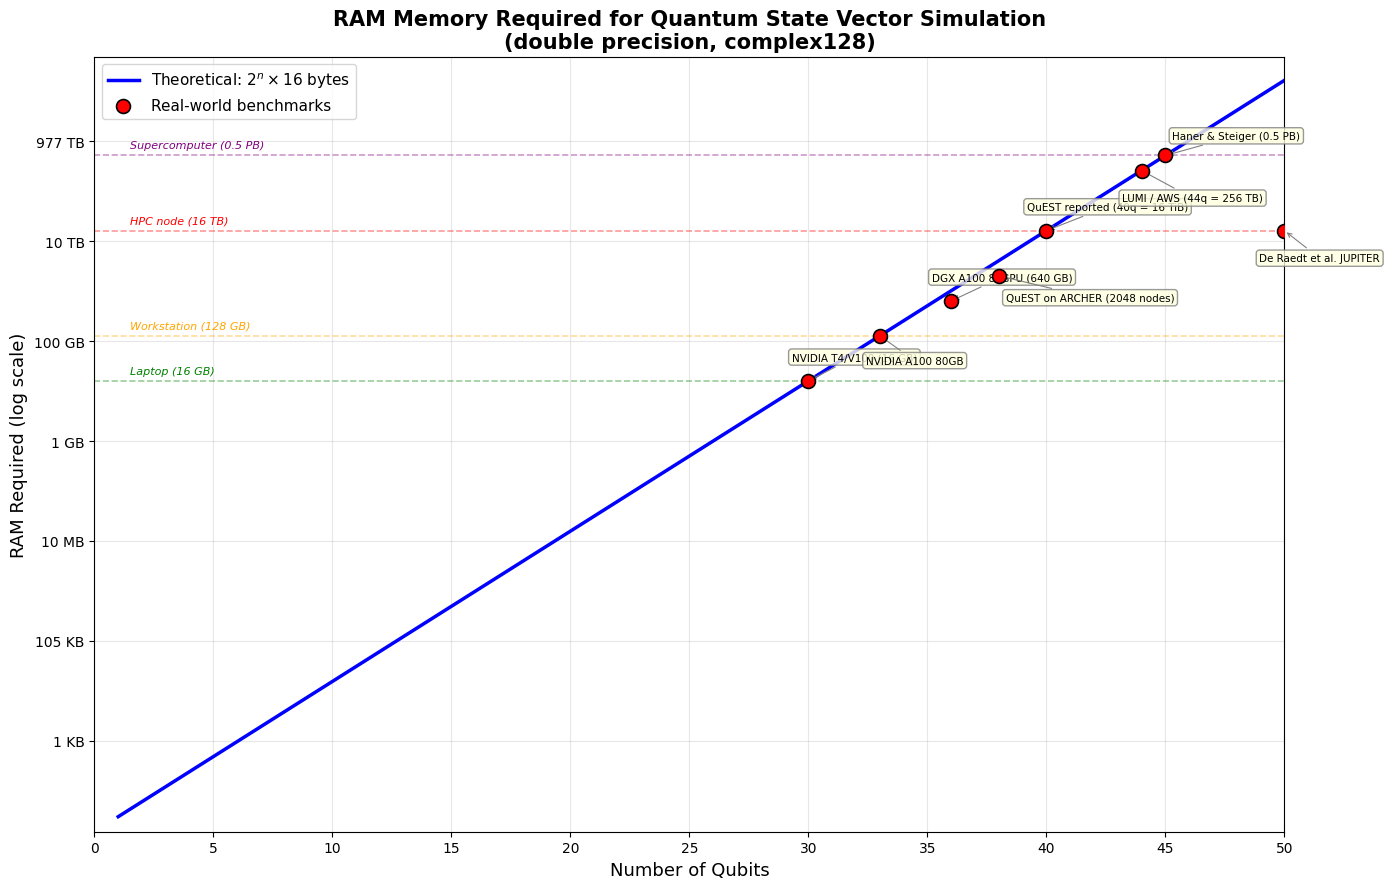

Plot saved to quantum_ram_requirements.png


In [3]:
# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 9))

# Theoretical curve
ax.semilogy(qubits, memory_gb, 'b-', linewidth=2.5, label=r'Theoretical: $2^n \times 16$ bytes', zorder=2)

# Real data points
ax.scatter(real_qubits, real_mem_gb, color='red', s=100, zorder=5, edgecolors='black', linewidths=1.2,
           label='Real-world benchmarks')

# Annotate real data points
offsets = {
    "NVIDIA T4/V100 (16 GB)":       (-12, 15),
    "NVIDIA A100 80GB":              (-10, -20),
    "DGX A100 8xGPU (640 GB)":       (-14, 15),
    "QuEST on ARCHER (2048 nodes)":  (5, -18),
    "QuEST reported (40q = 16 TiB)": (-14, 15),
    "LUMI / AWS (44q = 256 TB)":     (-14, -22),
    "Haner & Steiger (0.5 PB)":      (5, 12),
    "De Raedt et al. JUPITER":       (-18, -22),
}
for label, (q, mem, ref) in real_data.items():
    ox, oy = offsets.get(label, (5, 10))
    ax.annotate(f"{label}", xy=(q, mem), xytext=(ox, oy),
                textcoords='offset points', fontsize=7.5,
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.8),
                bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray', alpha=0.8))

# Hardware tiers (horizontal lines)
tiers = [
    (16,         'Laptop (16 GB)',         'green'),
    (128,        'Workstation (128 GB)',   'orange'),
    (16 * 1024,  'HPC node (16 TB)',       'red'),
    (512 * 1024, 'Supercomputer (0.5 PB)', 'purple'),
]
for mem_gb_val, tier_label, color in tiers:
    ax.axhline(y=mem_gb_val, color=color, linestyle='--', alpha=0.4, linewidth=1.2)
    ax.text(1.5, mem_gb_val * 1.4, tier_label, fontsize=8, color=color, fontstyle='italic')

# Formatting
ax.set_xlabel('Number of Qubits', fontsize=13)
ax.set_ylabel('RAM Required (log scale)', fontsize=13)
ax.set_title('RAM Memory Required for Quantum State Vector Simulation\n(double precision, complex128)',
             fontsize=15, fontweight='bold')

# Custom y-axis labels in human-readable units
def format_memory(y, pos):
    if y < 1/1024:
        return f"{y * 1024**2:.0f} KB"
    elif y < 1:
        return f"{y * 1024:.0f} MB"
    elif y < 1024:
        return f"{y:.0f} GB"
    elif y < 1024**2:
        return f"{y/1024:.0f} TB"
    else:
        return f"{y/1024**2:.0f} PB"

ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_memory))
ax.set_xlim(1, 50)
ax.set_ylim(memory_gb[0] * 0.5, memory_gb[-1] * 3)
ax.set_xticks(range(0, 51, 5))
ax.grid(True, alpha=0.3, which='both')
ax.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.savefig('quantum_ram_requirements.png', dpi=200, bbox_inches='tight')
plt.show()

print("Plot saved to quantum_ram_requirements.png")

In [4]:
# --- Summary Table ---
print(f"{'Qubits':>7} | {'State Vector Size':>20} | {'RAM (complex128)':>18} | {'Hardware Tier'}")
print("-" * 85)

tier_map = {
    5:  "Trivial",
    10: "Trivial",
    15: "Trivial",
    20: "Any device",
    25: "Laptop (8 GB)",
    28: "Laptop (8 GB) - practical limit",
    30: "Laptop (16 GB) / GPU T4, V100",
    33: "GPU A100 (80 GB)",
    35: "Multi-GPU workstation",
    37: "HPC cluster",
    40: "Large HPC (16 TB) [Jones et al. 2019]",
    44: "Supercomputer - LUMI, AWS (256 TB) [FiQCI 2025]",
    45: "Supercomputer - 0.5 PB [Haner & Steiger 2017]",
    48: "Supercomputer [De Raedt et al. 2019]",
    50: "Exascale - JUPITER, ~2 PB w/ compression [De Raedt et al. 2025]",
    53: "Google Sycamore - INFEASIBLE (128 PB needed) [Arute et al. 2019]",
}

for n in [5, 10, 15, 20, 25, 28, 30, 33, 35, 37, 40, 44, 45, 48, 50, 53]:
    mem_b = 2**n * 16
    entries = 2**n
    if mem_b < 1024:
        mem_str = f"{mem_b} B"
    elif mem_b < 1024**2:
        mem_str = f"{mem_b / 1024:.0f} KB"
    elif mem_b < 1024**3:
        mem_str = f"{mem_b / 1024**2:.0f} MB"
    elif mem_b < 1024**4:
        mem_str = f"{mem_b / 1024**3:.0f} GB"
    elif mem_b < 1024**5:
        mem_str = f"{mem_b / 1024**4:.0f} TB"
    else:
        mem_str = f"{mem_b / 1024**5:.0f} PB"
    
    tier = tier_map.get(n, "")
    print(f"{n:>7} | {entries:>20,} | {mem_str:>18} | {tier}")

 Qubits |    State Vector Size |   RAM (complex128) | Hardware Tier
-------------------------------------------------------------------------------------
      5 |                   32 |              512 B | Trivial
     10 |                1,024 |              16 KB | Trivial
     15 |               32,768 |             512 KB | Trivial
     20 |            1,048,576 |              16 MB | Any device
     25 |           33,554,432 |             512 MB | Laptop (8 GB)
     28 |          268,435,456 |               4 GB | Laptop (8 GB) - practical limit
     30 |        1,073,741,824 |              16 GB | Laptop (16 GB) / GPU T4, V100
     33 |        8,589,934,592 |             128 GB | GPU A100 (80 GB)
     35 |       34,359,738,368 |             512 GB | Multi-GPU workstation
     37 |      137,438,953,472 |               2 TB | HPC cluster
     40 |    1,099,511,627,776 |              16 TB | Large HPC (16 TB) [Jones et al. 2019]
     44 |   17,592,186,044,416 |             256 TB 